Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


CWD = /content


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/620M [00:00<?, ?B/s]

Keyword argument `use_fast` is not a valid argument for this processor and will be ignored.


triangle 0.43696585297584534 [209.11447143554688, 25.174331665039062, 420.10986328125, 243.34962463378906]
square 0.5065644979476929 [215.86669921875, 183.67160034179688, 348.89556884765625, 315.55621337890625]
square 0.4277365803718567 [102.15447235107422, 341.1190185546875, 309.2794494628906, 553.8763427734375]
square 0.36545827984809875 [242.27978515625, 367.3685302734375, 437.92926025390625, 594.4671630859375]


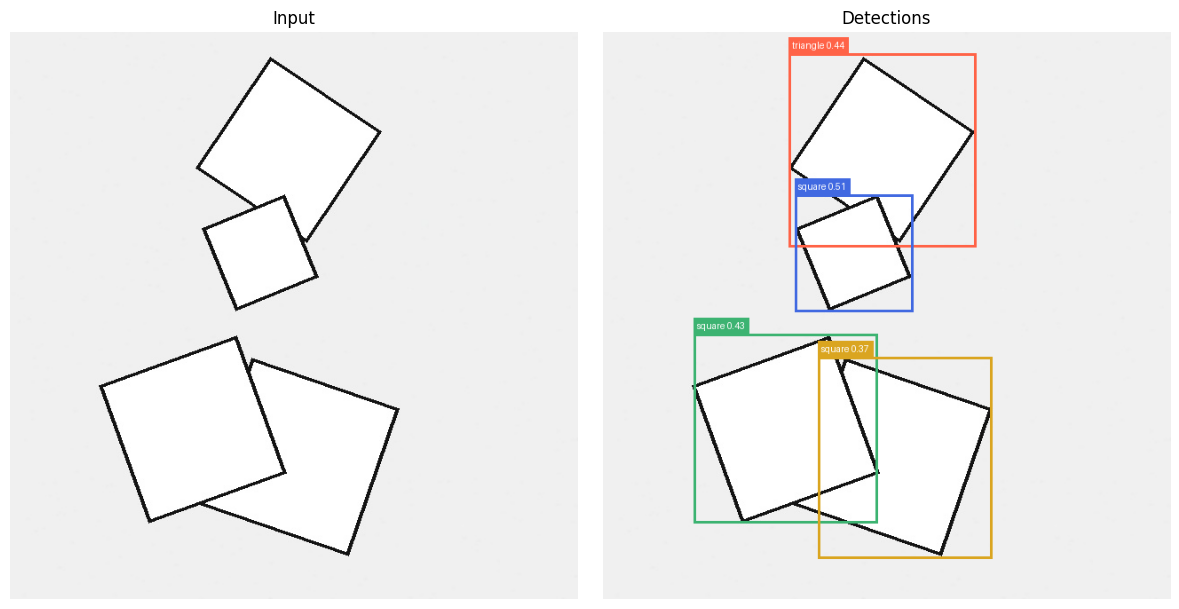

In [1]:
from transformers import Owlv2Processor, Owlv2ForObjectDetection
import torch
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from pathlib import Path
print("CWD =", Path.cwd())

processor = Owlv2Processor.from_pretrained("google/owlv2-base-patch16")
model     = Owlv2ForObjectDetection.from_pretrained("google/owlv2-base-patch16")

image = Image.open("figures/demo_01.jpg").convert("RGB")
texts = [["triangle", "circle", "square"]]   # prompts
inputs = processor(text=texts, images=image, return_tensors="pt", use_fast=True)
with torch.inference_mode():
    outputs = model(**inputs)

results = processor.post_process_grounded_object_detection(outputs, threshold=0.3, target_sizes=[image.size[::-1]])[0]
for box, score, label in zip(results["boxes"], results["scores"], results["labels"]):
    print(texts[0][label], float(score), box.tolist())

# Visualize detections
vis = image.copy()
draw = ImageDraw.Draw(vis)

# Try a readable font (falls back if not found)
try:
    font = ImageFont.truetype("arial.ttf", 18)
except OSError:
    font = ImageFont.load_default()

# small color palette
palette = [
    (255, 99, 71),   # tomato
    (65, 105, 225),  # royal blue
    (60, 179, 113),  # medium sea green
    (218, 165, 32),  # goldenrod
    (199, 21, 133),  # medium violet red
]

boxes  = results["boxes"]   # [N, 4] in pixel coords [x0,y0,x1,y1]
scores = results["scores"]  # [N]
labels = results["labels"]  # [N] indices into your prompt list

for i, (box, score, lab) in enumerate(zip(boxes, scores, labels)):
    x0, y0, x1, y1 = map(lambda v: int(round(float(v))), box)
    color = palette[i % len(palette)]

    # rectangle
    draw.rectangle([x0, y0, x1, y1], outline=color, width=3)

    # caption
    name = texts[0][int(lab)]
    caption = f"{name} {float(score):.2f}"
    # text background
    tw, th = draw.textbbox((0, 0), caption, font=font)[2:]
    bg = [x0, max(0, y0 - th - 6), x0 + tw + 8, y0]
    draw.rectangle(bg, fill=color)
    draw.text((x0 + 4, bg[1] + 3), caption, fill=(255, 255, 255), font=font)

# show side-by-side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(image); plt.title("Input"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(vis);   plt.title("Detections"); plt.axis("off")
plt.tight_layout()
plt.show()

CWD = /content


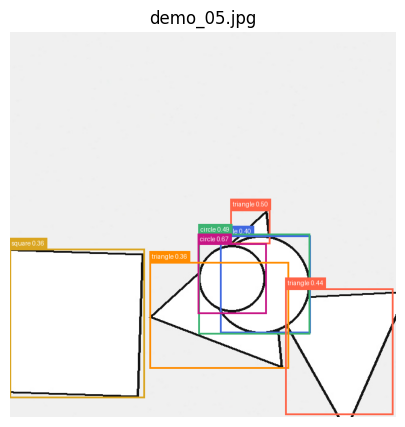

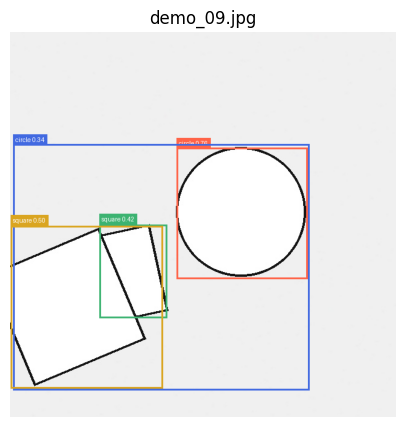

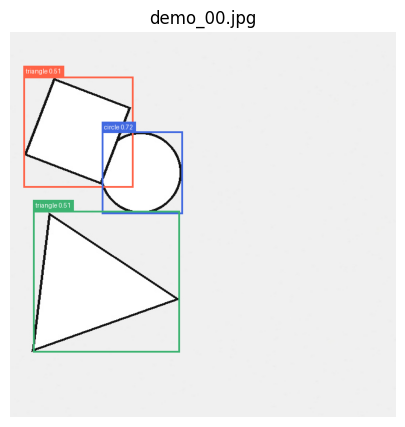

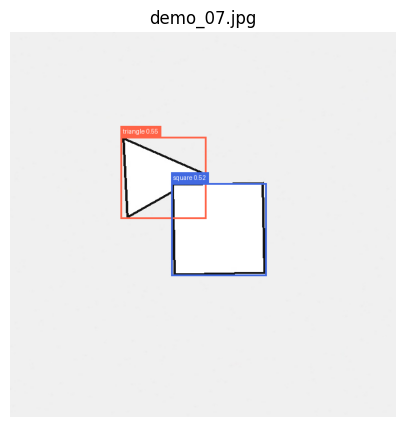

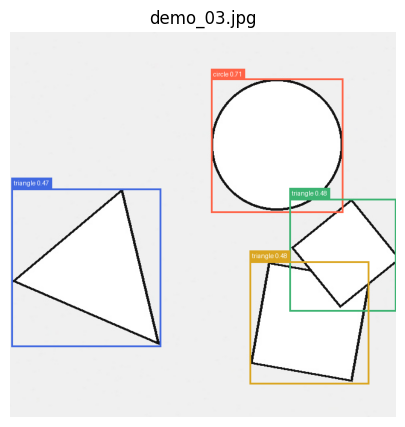

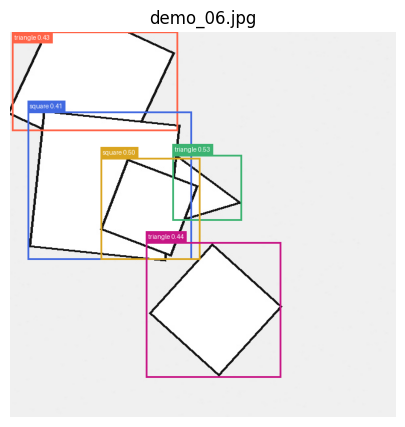

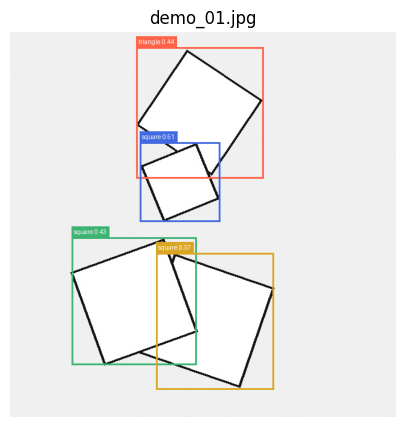

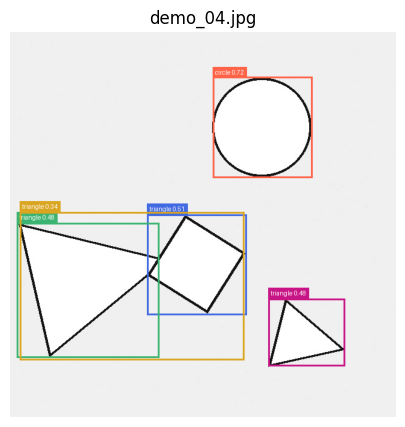

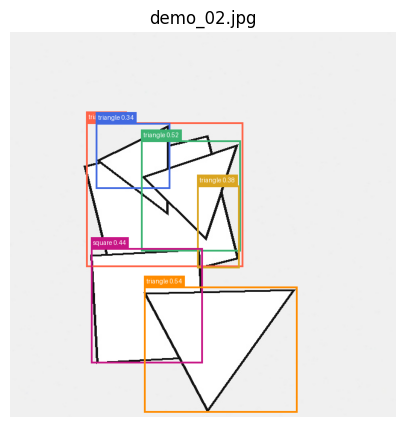

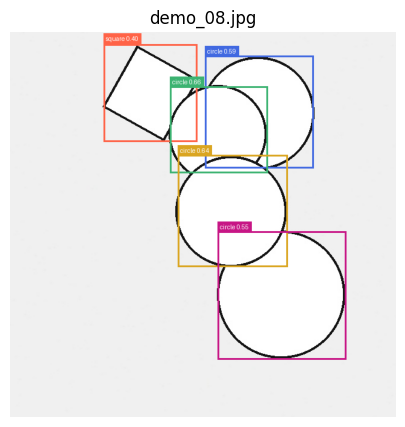


--- Summary ---
Detections per class:
  circle    : predicted= 12, ground_truth= 10, diff= +2
  square    : predicted= 11, ground_truth= 19, diff= -8
  triangle  : predicted= 22, ground_truth= 11, diff=+11

Overall detection accuracy (total count): 87.50%
Mean per-class accuracy:                 45.96%


In [2]:
from transformers import Owlv2Processor, Owlv2ForObjectDetection
import torch
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os

print("CWD =", Path.cwd())

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load model and processor
processor = Owlv2Processor.from_pretrained("google/owlv2-base-patch16")
model     = Owlv2ForObjectDetection.from_pretrained("google/owlv2-base-patch16").to(DEVICE)

# === Define all classes you want to detect (extend this list as needed)
classes = ["circle", "square", "triangle"]
prompts = [classes]  # OWLv2 expects a list of list for multiple prompts

# === Load all images from folder
fig_dir = Path("figures")
images = [p for p in fig_dir.glob("*.jpg")] + [p for p in fig_dir.glob("*.png")]

# === Accuracy & counting metrics
correct = 0
total   = 0
counts  = {cls: 0 for cls in classes}

def draw_boxes(image, results, labels):
    vis = image.copy()
    draw = ImageDraw.Draw(vis)

    try:
        font = ImageFont.truetype("arial.ttf", 18)
    except OSError:
        font = ImageFont.load_default()

    palette = [
        (255, 99, 71), (65, 105, 225),
        (60, 179, 113), (218, 165, 32),
        (199, 21, 133), (255, 140, 0)
    ]

    for i, (box, score, lab) in enumerate(zip(results["boxes"], results["scores"], results["labels"])):
        x0, y0, x1, y1 = map(int, box.tolist())
        color = palette[i % len(palette)]
        name = labels[int(lab)]
        caption = f"{name} {score:.2f}"

        # rectangle for object
        draw.rectangle([x0, y0, x1, y1], outline=color, width=3)

        # compute text box safely
        tw, th = draw.textbbox((0, 0), caption, font=font)[2:]
        # make sure the text background is inside the image
        y_text_top = max(0, y0 - th - 6)
        y_text_bottom = max(y_text_top + th + 6, y0)
        bg = [x0, y_text_top, x0 + tw + 8, y_text_bottom]

        # draw text background safely (only if valid)
        if bg[3] > bg[1]:
            draw.rectangle(bg, fill=color)

        # draw text
        draw.text((x0 + 4, y_text_top + 3), caption, fill=(255, 255, 255), font=font)

    return vis



# === Process each image
for img_path in images:
    image = Image.open(img_path).convert("RGB")

    # Detect
    inputs = processor(text=prompts, images=image, return_tensors="pt").to(DEVICE)
    with torch.inference_mode():
        outputs = model(**inputs)
    results = processor.post_process_grounded_object_detection(
        outputs, threshold=0.3, target_sizes=[image.size[::-1]]
    )[0]

    # Count detections by class
    for lab in results["labels"]:
        cls = classes[int(lab)]
        counts[cls] += 1

    # Visualize results
    vis = draw_boxes(image, results, classes)
    plt.figure(figsize=(10, 5))
    plt.imshow(vis)
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

# === Ground truth (ręcznie policzone wartości)
gt_counts = {"triangle": 11, "circle": 10, "square": 19}

# === Porównanie predykcji z ground truth
print("\n--- Summary ---")
print("Detections per class:")
for k, v in counts.items():
    gt = gt_counts.get(k, 0)
    diff = v - gt
    print(f"  {k:10s}: predicted={v:3d}, ground_truth={gt:3d}, diff={diff:+3d}")

# === Obliczenie accuracy (proste dopasowanie liczby wykryć)
# Można to interpretować jako: 1 - (średni względny błąd liczby wykryć)
abs_errors = [abs(counts[k] - gt_counts.get(k, 0)) for k in gt_counts]
total_gt = sum(gt_counts.values())
total_pred = sum(counts.values())

# globalna dokładność względem łącznej liczby kształtów
accuracy_total = 1 - abs(total_pred - total_gt) / total_gt if total_gt > 0 else 0.0

# średnia dokładność per klasa
acc_per_class = np.mean([
    1 - abs(counts[k] - gt_counts[k]) / gt_counts[k] if gt_counts[k] > 0 else 0
    for k in gt_counts
])

print(f"\nOverall detection accuracy (total count): {accuracy_total:.2%}")
print(f"Mean per-class accuracy:                 {acc_per_class:.2%}")


In [3]:
from transformers import Owlv2Processor, Owlv2ForObjectDetection
import torch
from PIL import Image
from pathlib import Path
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

processor = Owlv2Processor.from_pretrained("google/owlv2-base-patch16")
model     = Owlv2ForObjectDetection.from_pretrained("google/owlv2-base-patch16").to(DEVICE)

# klasa → nazwa
classes = ["triangle", "square", "circle"]
prompts = [classes]

# -----------------------
#   Ground truth per plik
# -----------------------
gt = {
    "demo_00.jpg": {"triangle": 1, "square": 1, "circle": 1},
    "demo_01.jpg": {"triangle": 0, "square": 4, "circle": 0},
    "demo_02.jpg": {"triangle": 3, "square": 2, "circle": 0},
    "demo_03.jpg": {"triangle": 1, "square": 2, "circle": 1},
    "demo_04.jpg": {"triangle": 2, "square": 1, "circle": 1},
    "demo_05.jpg": {"triangle": 2, "square": 1, "circle": 2},
    "demo_06.jpg": {"triangle": 1, "square": 4, "circle": 0},
    "demo_07.jpg": {"triangle": 1, "square": 1, "circle": 0},
    "demo_08.jpg": {"triangle": 0, "square": 1, "circle": 4},
    "demo_09.jpg": {"triangle": 0, "square": 2, "circle": 1},
}

# -----------------------
#     Predykcje per plik
# -----------------------
fig_dir = Path("figures")
images = sorted(list(fig_dir.glob("*.jpg")) + list(fig_dir.glob("*.png")))

pred = {}  # tu zapiszą się wyniki per plik

for img_path in images:
    image = Image.open(img_path).convert("RGB")

    inputs = processor(text=prompts, images=image, return_tensors="pt").to(DEVICE)
    with torch.inference_mode():
        outputs = model(**inputs)

    results = processor.post_process_grounded_object_detection(
        outputs, threshold=0.3, target_sizes=[image.size[::-1]]
    )[0]

    file_counts = {cls: 0 for cls in classes}
    for lab in results["labels"]:
        label = classes[int(lab)]
        file_counts[label] += 1

    pred[img_path.name] = file_counts


# -----------------------
#  PORÓWNANIE I ACCURACY
# -----------------------

def file_accuracy(gt_counts, pred_counts):
    acc = []
    for cls in classes:
        g = gt_counts[cls]
        p = pred_counts[cls]
        if g == 0 and p == 0:
            acc.append(1.0)
        elif g == 0 and p > 0:
            acc.append(0.0)
        else:
            acc.append(1 - abs(g - p) / g)
    return np.mean(acc)

print("\n==================== RESULTS PER FILE ====================\n")
total_gt = {c: 0 for c in classes}
total_pred = {c: 0 for c in classes}

for fname in pred:
    print(f"--- {fname} ---")
    print("GT:   ", gt[fname])
    print("Pred: ", pred[fname])

    acc = file_accuracy(gt[fname], pred[fname])
    print(f"Accuracy: {acc:.2%}\n")

    # globalne sumy
    for c in classes:
        total_gt[c] += gt[fname][c]
        total_pred[c] += pred[fname][c]


# -----------------------
#     GLOBAL ACCURACY
# -----------------------

print("\n==================== GLOBAL SUMMARY ====================\n")

print("Total GT:   ", total_gt)
print("Total Pred: ", total_pred)

# accuracy per klasa
print("\nAccuracy per class:")
for c in classes:
    g = total_gt[c]
    p = total_pred[c]

    if g == 0 and p == 0:
        acc = 1.0
    elif g == 0:
        acc = 0.0
    else:
        acc = 1 - abs(g - p) / g

    print(f"  {c:10s}: {acc:.2%}")

# globalne accuracy
gt_sum = sum(total_gt.values())
pred_sum = sum(total_pred.values())

global_acc = 1 - abs(gt_sum - pred_sum) / gt_sum
print(f"\nOverall global accuracy: {global_acc:.2%}")



==================== RESULTS PER FILE ====================

--- demo_00.jpg ---
GT:    {'triangle': 1, 'square': 1, 'circle': 1}
Pred:  {'triangle': 2, 'square': 0, 'circle': 1}
Accuracy: 33.33%

--- demo_01.jpg ---
GT:    {'triangle': 0, 'square': 4, 'circle': 0}
Pred:  {'triangle': 1, 'square': 3, 'circle': 0}
Accuracy: 58.33%

--- demo_02.jpg ---
GT:    {'triangle': 3, 'square': 2, 'circle': 0}
Pred:  {'triangle': 5, 'square': 1, 'circle': 0}
Accuracy: 61.11%

--- demo_03.jpg ---
GT:    {'triangle': 1, 'square': 2, 'circle': 1}
Pred:  {'triangle': 3, 'square': 0, 'circle': 1}
Accuracy: 0.00%

--- demo_04.jpg ---
GT:    {'triangle': 2, 'square': 1, 'circle': 1}
Pred:  {'triangle': 4, 'square': 0, 'circle': 1}
Accuracy: 33.33%

--- demo_05.jpg ---
GT:    {'triangle': 2, 'square': 1, 'circle': 2}
Pred:  {'triangle': 3, 'square': 1, 'circle': 3}
Accuracy: 66.67%

--- demo_06.jpg ---
GT:    {'triangle': 1, 'square': 4, 'circle': 0}
Pred:  {'triangle': 3, 'square': 2, 'circle': 0}
Accura